# IMPLEMENT COSINE SCHEDULER

We begin with a toy problem that is cheap enough to compute easily, yet sufficiently nontrivial to illustrate some of the key aspects. For that we pick a slightly modernized version of LeNet (relu instead of sigmoid activation, MaxPooling rather than AveragePooling), as applied to Fashion-MNIST. Moreover, we hybridize the network for performance.

In [1]:
%matplotlib inline
import math
import torch
from torch import nn
from utils import spy

In [2]:
def net_fn():
    model = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
        nn.Linear(120, 84), nn.ReLU(),
        nn.Linear(84, 10)
    )
    return model

In [3]:
loss = nn.CrossEntropyLoss()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 256

fashion_mnist = spy.FashionMNIST(batch_size=batch_size, resize=None, root='../../data/fashion-mnist')
train_iter = fashion_mnist.get_dataloader(train=True)
test_iter = fashion_mnist.get_dataloader(train=False)

Next, we define the train function.

In [ ]:
from torch.optim import lr_scheduler

def train(net, train_iter, test_iter, num_epochs, loss, trainer, 
          device, scheduler=None):
    net.to(device)
    animator = spy.Animator(xlabel='epoch', ylabel='loss', xlim=[0, num_epochs], 
                            legend=['train_loss', 'train_acc', 'test_acc'])
    train_loss, train_acc = 0.0, 0.0

    for epoch in range(num_epochs):
        metric = spy.Accumulator(3)      # train_loss, train_acc, num_examples
        for i, (X, y) in enumerate(train_iter):
            net.train()
            trainer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            trainer.step()
            
            with torch.no_grad():
                metric.add(l * X.shape[0], spy.accuracy(y_hat, y, False), X.shape[0])
            
            train_loss = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % 50 == 0:
                animator.add(epoch + i / len(train_iter), (train_loss, train_acc, None))

        test_acc = spy.evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))

        if scheduler:
            # Using pytorch built-in scheduler
            if scheduler.__module__ == lr_scheduler.__name__:
                scheduler.step()
            else:
                # Using custom defined scheduler
                for param_group in trainer.param_groups:
                    param_group['lr'] = scheduler(epoch)

    print(f'Train loss: {train_loss:.3f}\n'
          f'Train acc: {train_acc:.3f}\n'
          f'Test acc: {test_acc:.3f}')


## Cosine Scheduler

It relies on the observation that we might not want to decrease the learning rate too drastically in the beginning and moreover, that we might want to “refine” the solution in the end using a very small learning rate. This results in a cosine-like schedule with the following functional form for learning rates in the range $t \in (0, T)$

$\eta_t= \eta_T+ \frac{\eta_0 - \eta_T}{2}  \left( 1 + \cos\!\left( \frac{\pi t}{T} \right) \right),\qquad t \in [0, T]$

Here $\eta_0$ is the initial learning rate, $\eta_T$ is the target rate at time $T$. Furthermore, for $t > T$ we simply pin the value to 
$\eta_T$ without increasing it again. In the following example, we set the max update step $T = 20$.

In some cases initializing the parameters is not sufficient to guarantee a good solution. This is particularly a problem for some advanced network designs that may lead to unstable optimization problems. We could address this by choosing a sufficiently small learning rate to prevent divergence in the beginning. Unfortunately this means that progress is slow. Conversely, a large learning rate initially leads to divergence.

A rather simple fix for this dilemma is to use a warmup period during which the learning rate increases to its initial maximum and to cool down the rate until the end of the optimization process. For simplicity one typically uses a linear increase for this purpose.

In [5]:
class CosineScheduler:
    def __init__(self, max_update, base_lr=0.01, final_lr=0, warmup_steps=0, warmup_begin_lr=0):
        self.base_lr_orig = base_lr
        self.max_update = max_update
        self.final_lr = final_lr
        self.warmup_steps = warmup_steps
        self.warmup_begin_lr = warmup_begin_lr
        self.max_steps = self.max_update - self.warmup_steps


    def get_warmup(self, epoch):
        increase = (self.base_lr_orig - self.warmup_begin_lr) * float(epoch) / float(self.warmup_steps)
        return self.warmup_begin_lr + increase
    

    def __call__(self, epoch):
        if epoch < self.warmup_steps:
            return self.get_warmup(epoch)
        if epoch < self.max_update:
            self.base_lr = self.final_lr + (self.base_lr_orig - self.final_lr) * (1 + math.cos(
                math.pi * (epoch - self.warmup_steps) / self.max_steps)) / 2
            
        return self.base_lr

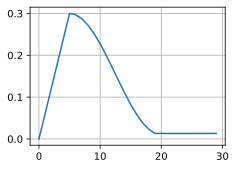

In [6]:
num_epochs = 30
scheduler = CosineScheduler(max_update=20, warmup_steps=5, base_lr=0.3, final_lr=0.01)
spy.plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

Train loss: 0.23198009990056356:.3fTrain acc: 0.91475:.3fTest acc: 0.8863:.3f


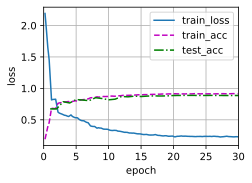

In [8]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=0.3)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device, scheduler)

A warmup phase limits the amount of divergence of parameters in very deep networks. This makes intuitively sense since we would expect significant divergence due to random initialization in those parts of the network that take the most time to make progress in the beginning.